In [74]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.25, random_state=42
)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.55      0.16      0.24        38
           1       0.52      0.87      0.65        39

    accuracy                           0.52        77
   macro avg       0.53      0.51      0.45        77
weighted avg       0.53      0.52      0.45        77



In [75]:
import pandas as pd

df = pd.read_csv("/home/henrykabuye/Ransap/Publications 2026/Proposal_2026/Knowledge_Agent/outputs/Knowledge_Agent_Features_307.csv")

# target
y = (df["Family_Count"] > 0).astype(int)

# drop non-feature columns + leakage column
drop_cols = [
    "Video_ID",
    "Channel_ID",
    "Channel_Name",
    "Video_Title",
    "YouTube_URL",
    "Transcript_Path",
    "Family_List",
    "Tool_List",
    "Dominant_Tactic",
    "Platform_Signal",
    "Family_Count"   # critical: remove leakage
]

X = df.drop(columns=drop_cols, errors="ignore")
X = X.select_dtypes(include="number")

print("Feature matrix shape:", X.shape)
print("Contains Family_Count?", "Family_Count" in X.columns)
print("Example features:")
print(X.columns[:15])


Feature matrix shape: (307, 23)
Contains Family_Count? False
Example features:
Index(['Tool_Total_Mentions', 'Tactic_Total_Mentions', 'Tactic_Initial_Access',
       'Tactic_Execution', 'Tactic_Persistence', 'Tactic_Privilege_Escalation',
       'Tactic_Credential_Access', 'Tactic_Lateral_Movement',
       'Tactic_Discovery', 'Tactic_Command_and_Control', 'Tactic_Exfiltration',
       'Tactic_Impact', 'Tool_Cobalt_Strike', 'Tool_Mimikatz', 'Tool_PsExec'],
      dtype='object')


In [76]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       0.41      0.21      0.28        33
           1       0.57      0.77      0.65        44

    accuracy                           0.53        77
   macro avg       0.49      0.49      0.47        77
weighted avg       0.50      0.53      0.49        77


Confusion matrix:
[[ 7 26]
 [10 34]]


In [77]:
import numpy as np
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression

probs = []

for i in range(50):
    Xb, yb = resample(X_train, y_train, replace=True, random_state=42 + i)
    m = LogisticRegression(max_iter=2000)
    m.fit(Xb, yb)
    p = m.predict_proba(X_test)[:, 1]
    probs.append(p)

probs = np.array(probs)

s_know = probs.mean(axis=0)
sigma_know = probs.std(axis=0)

know_out = df.loc[X_test.index, ["Video_ID"]].copy()
know_out["s_know"] = s_know
know_out["sigma_know"] = sigma_know

know_out.head()

,Video_ID,s_know,sigma_know
109,V0158,0.550918,0.059832
270,V0008,0.252192,0.178219
172,V0182,0.557251,0.053774
25,V0039,0.652447,0.062775
131,V0053,0.548268,0.050840


In [78]:
out_path = "/home/henrykabuye/Ransap/Publications 2026/Proposal_2026/Knowledge_Agent/outputs/Knowledge_Agent_Output.csv"
know_out.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /home/henrykabuye/Ransap/Publications 2026/Proposal_2026/Knowledge_Agent/outputs/Knowledge_Agent_Output.csv


In [79]:
import pandas as pd

df = pd.read_csv("/home/henrykabuye/Ransap/Publications 2026/Proposal_2026/Knowledge_Agent/outputs/Knowledge_Agent_Output.csv")

print("Average knowledge score:", df["s_know"].mean())
print("Average uncertainty:", df["sigma_know"].mean())

print("\nHigh uncertainty samples:")
print(df.sort_values("sigma_know", ascending=False).head(10))

Average knowledge score: 0.5636572373560933
Average uncertainty: 0.10988985813999767

High uncertainty samples:
   Video_ID    s_know  sigma_know
35    V0173  0.582773    0.453976
8     V0070  0.279806    0.410173
43    V0009  0.291169    0.282469
7     V0391  0.558703    0.267635
40    V0030  0.327670    0.266554
32    V0181  0.859717    0.249649
65    V0376  0.362739    0.249578
51    V0388  0.533250    0.241794
25    V0278  0.384413    0.215110
47    V0056  0.384413    0.215110


In [80]:
import pandas as pd

df = pd.read_csv("/home/henrykabuye/Ransap/Publications 2026/Proposal_2026/Knowledge_Agent/outputs/Knowledge_Agent_Output.csv")

print("High uncertainty count:", (df["sigma_know"] > 0.25).sum())
print("Low uncertainty count:", (df["sigma_know"] < 0.05).sum())

High uncertainty count: 5
Low uncertainty count: 7


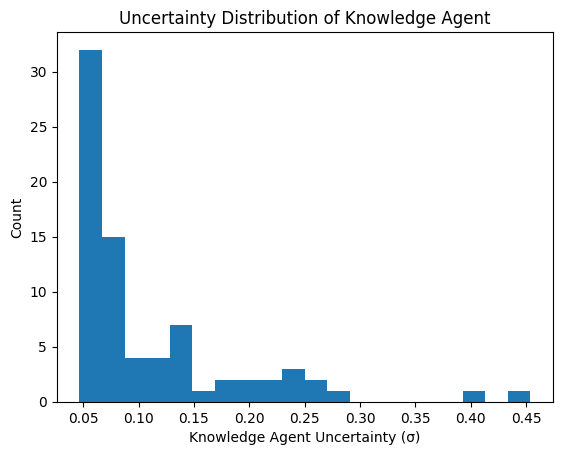

In [81]:
import matplotlib.pyplot as plt

plt.hist(df["sigma_know"], bins=20)
plt.xlabel("Knowledge Agent Uncertainty (σ)")
plt.ylabel("Count")
plt.title("Uncertainty Distribution of Knowledge Agent")
plt.show()

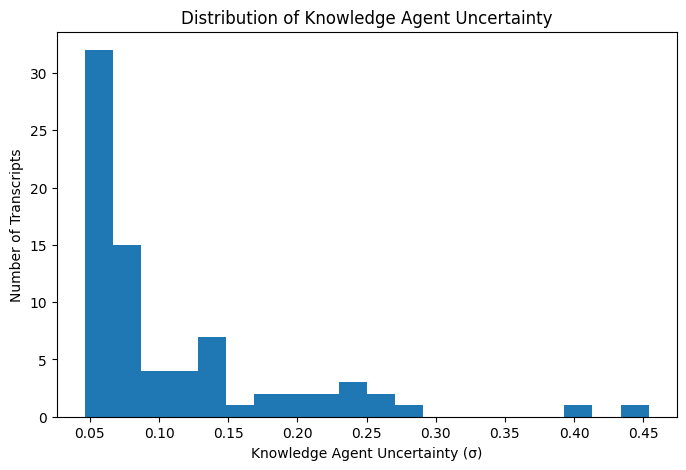

Figure saved to: /home/henrykabuye/Ransap/Publications 2026/Proposal_2026/Knowledge_Agent/outputs/Knowledge_Agent_Uncertainty_Distribution.png


In [82]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/home/henrykabuye/Ransap/Publications 2026/Proposal_2026/Knowledge_Agent/outputs/Knowledge_Agent_Output.csv")

plt.figure(figsize=(8,5))
plt.hist(df["sigma_know"], bins=20)

plt.xlabel("Knowledge Agent Uncertainty (σ)")
plt.ylabel("Number of Transcripts")
plt.title("Distribution of Knowledge Agent Uncertainty")

# Save the figure
save_path = "/home/henrykabuye/Ransap/Publications 2026/Proposal_2026/Knowledge_Agent/outputs/Knowledge_Agent_Uncertainty_Distribution.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved to:", save_path)

In [83]:
# Running Out of Distribution on "Play Ransomware family"

In [84]:
import pandas as pd

df = pd.read_csv("/home/henrykabuye/Ransap/Publications 2026/Proposal_2026/Knowledge_Agent/outputs/Knowledge_Agent_Features_307.csv")

In [85]:
df["Ransomware_Context"] = (
    (df["Tactic_Total_Mentions"] > 10) |
    (df["Tool_Total_Mentions"] > 2)
).astype(int)

In [86]:
df["Is_Play"] = df["Family_List"].str.contains("Play", na=False)

train_df = df[df["Is_Play"] == False].copy()
test_df  = df[df["Is_Play"] == True].copy()

print("Training samples:", len(train_df))
print("Play test samples:", len(test_df))

Training samples: 158
Play test samples: 149


In [87]:
drop_cols = [
"Video_ID",
"Channel_ID",
"Channel_Name",
"Video_Title",
"YouTube_URL",
"Transcript_Path",
"Family_List",
"Tool_List",
"Dominant_Tactic",
"Platform_Signal",
"Family_Count",
"Is_Play",
"Ransomware_Context"
]

X_train = train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
X_test  = test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

y_train = train_df["Ransomware_Context"]
y_test  = test_df["Ransomware_Context"]

In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93        83
           1       0.98      0.83      0.90        66

    accuracy                           0.92       149
   macro avg       0.93      0.91      0.92       149
weighted avg       0.93      0.92      0.92       149



In [90]:
print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())


Training label distribution:
Ransomware_Context
0    84
1    74
Name: count, dtype: int64

Test label distribution:
Ransomware_Context
0    83
1    66
Name: count, dtype: int64


In [91]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

scores = cross_val_score(model, X, y, cv=5, scoring="f1")

print("F1 scores:", scores)
print("Mean F1:", scores.mean())

F1 scores: [0.72727273 0.74725275 0.69767442 0.72093023 0.6744186 ]
Mean F1: 0.7135097460678856


In [92]:
import joblib
joblib.dump(model, "Knowledge_Agent_Model.pkl")

['Knowledge_Agent_Model.pkl']

In [71]:
import pandas as pd

importance = pd.Series(model.coef_[0], index=X_train.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(15))

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

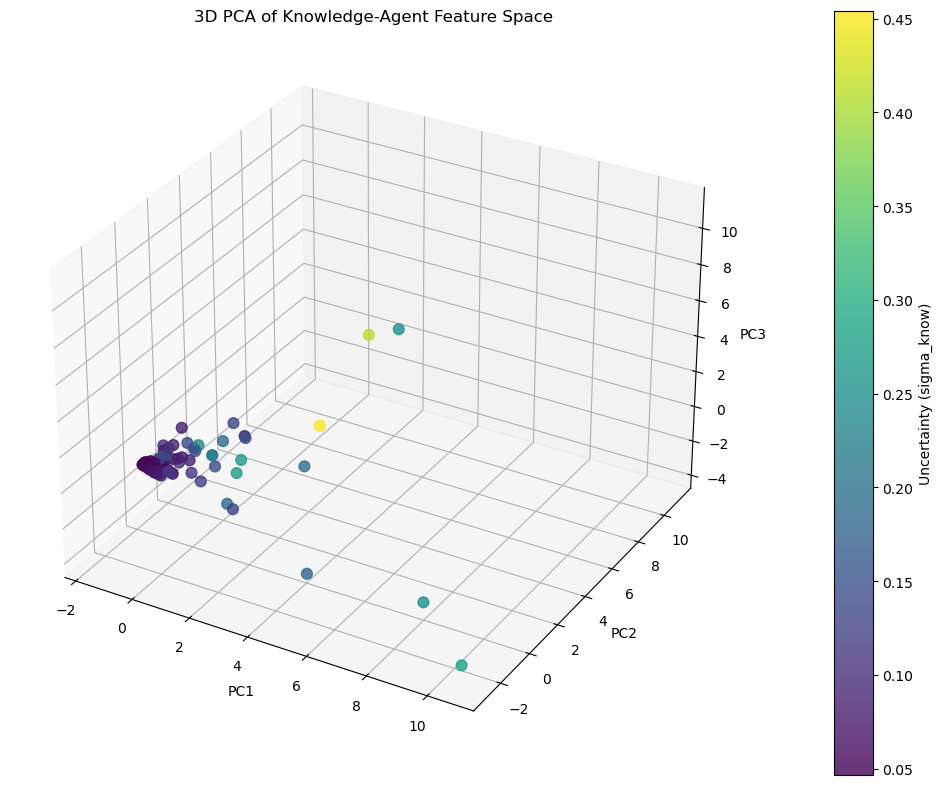

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load original feature data
df_full = pd.read_csv("/home/henrykabuye/Ransap/Publications 2026/Proposal_2026/Knowledge_Agent/outputs/Knowledge_Agent_Features_307.csv")
df_out  = pd.read_csv("/home/henrykabuye/Ransap/Publications 2026/Proposal_2026/Knowledge_Agent/outputs/Knowledge_Agent_Output.csv")

# Merge outputs back to source data
df_plot = df_full.merge(df_out, on="Video_ID", how="inner")

drop_cols = [
    "Video_ID",
    "Channel_ID",
    "Channel_Name",
    "Video_Title",
    "YouTube_URL",
    "Transcript_Path",
    "Family_List",
    "Tool_List",
    "Dominant_Tactic",
    "Platform_Signal",
    "Family_Count"
]

X_plot = df_plot.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

# Scale + PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_plot)

pca = PCA(n_components=3, random_state=42)
X_3d = pca.fit_transform(X_scaled)

df_plot["PC1"] = X_3d[:, 0]
df_plot["PC2"] = X_3d[:, 1]
df_plot["PC3"] = X_3d[:, 2]

# 3D plot colored by uncertainty
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    df_plot["PC1"],
    df_plot["PC2"],
    df_plot["PC3"],
    c=df_plot["sigma_know"],
    s=60,
    alpha=0.8
)

ax.set_title("3D PCA of Knowledge-Agent Feature Space")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Uncertainty (sigma_know)")

plt.tight_layout()
plt.show()

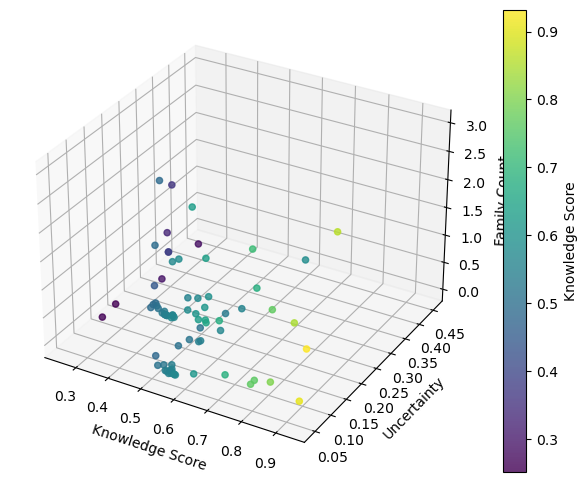

In [8]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    df_plot["s_know"],
    df_plot["sigma_know"],
    df_plot["Family_Count"],
    c=df_plot["s_know"],
    alpha=0.8
)

ax.set_xlabel("Knowledge Score")
ax.set_ylabel("Uncertainty")
ax.set_zlabel("Family Count")

plt.colorbar(sc, label="Knowledge Score")

plt.show()

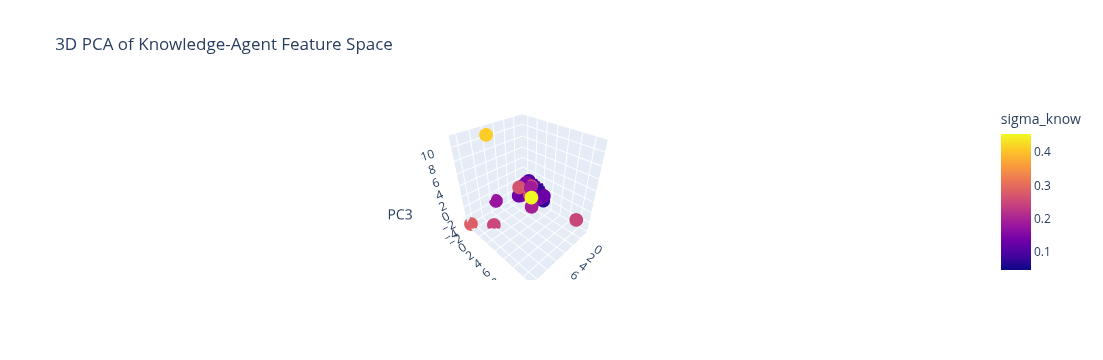

In [9]:
import plotly.express as px

fig = px.scatter_3d(
    df_plot,
    x="PC1",
    y="PC2",
    z="PC3",
    color="sigma_know",
    hover_data=["Video_ID", "s_know", "sigma_know", "Family_List"],
    title="3D PCA of Knowledge-Agent Feature Space"
)
fig.show()

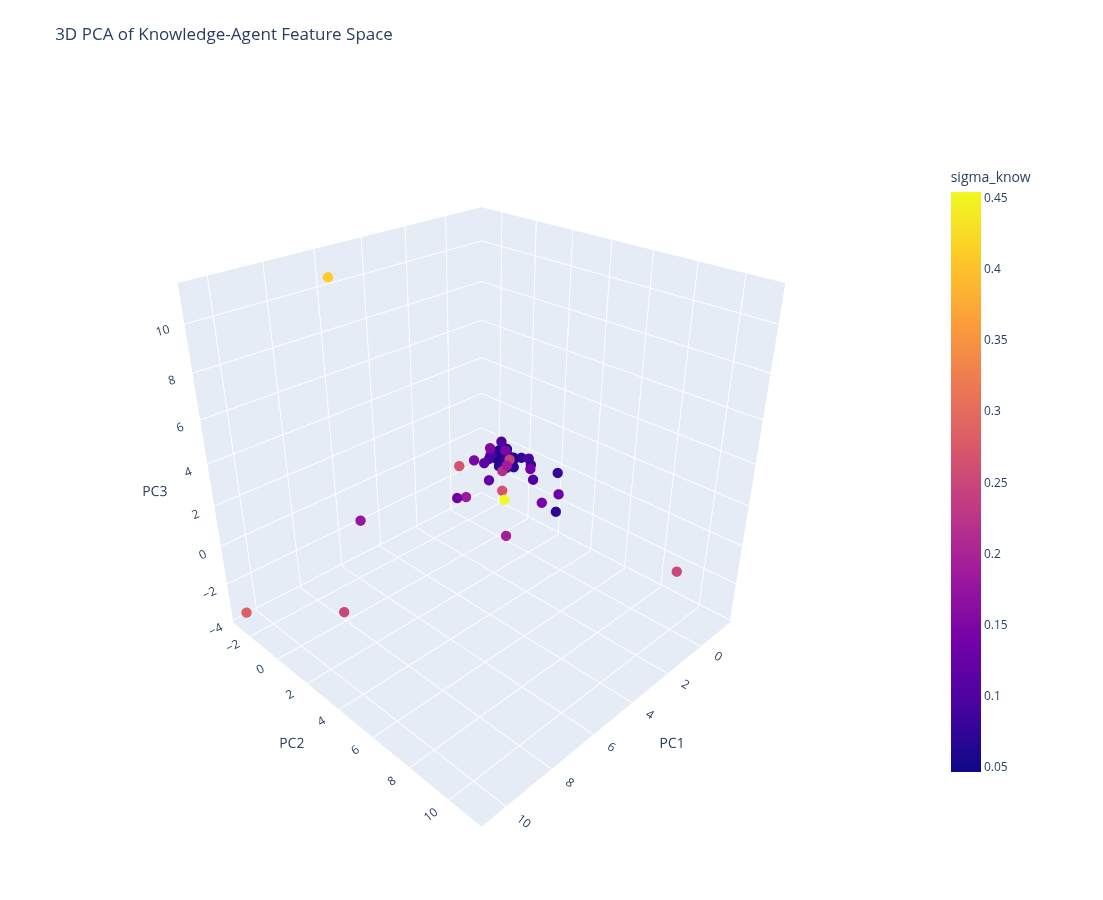

In [11]:
import plotly.express as px

fig = px.scatter_3d(
    df_plot,
    x="PC1",
    y="PC2",
    z="PC3",
    color="sigma_know",
    hover_data=["Video_ID", "s_know", "sigma_know", "Family_List"],
    title="3D PCA of Knowledge-Agent Feature Space"
)

fig.update_traces(marker=dict(size=6))

fig.update_layout(
    width=1400,
    height=900,
    margin=dict(l=40, r=180, b=40, t=80),  # bigger right margin
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3",
        aspectmode="cube",
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    coloraxis_colorbar=dict(
        title="sigma_know",
        x=1.02,      # move colorbar slightly right
        xanchor="left",
        len=0.8
    )
)

fig.show()

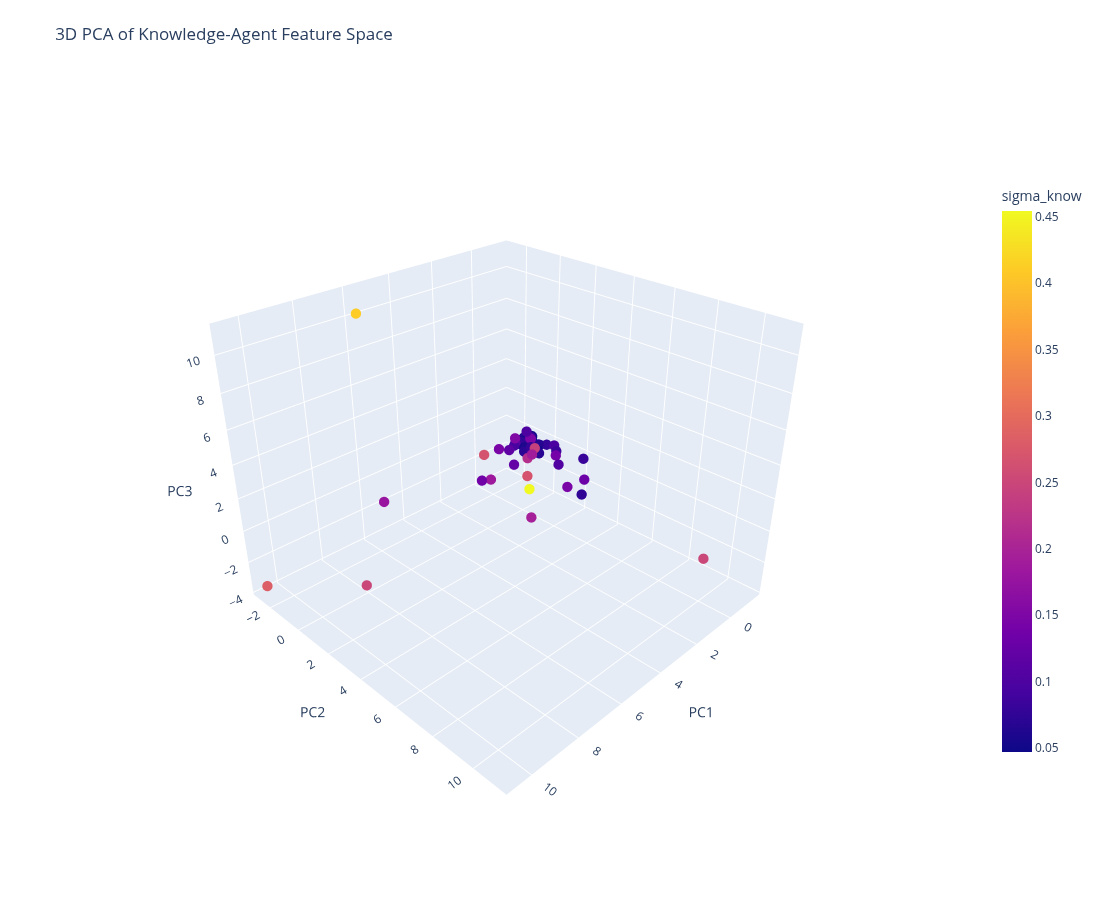

In [10]:
import plotly.express as px

fig = px.scatter_3d(
    df_plot,
    x="PC1",
    y="PC2",
    z="PC3",
    color="sigma_know",
    hover_data=["Video_ID", "s_know", "sigma_know", "Family_List"],
    title="3D PCA of Knowledge-Agent Feature Space"
)

fig.update_traces(marker=dict(size=6))

fig.update_layout(
    width=1400,
    height=900,
    margin=dict(l=40, r=40, b=40, t=80),
    scene=dict(
        xaxis=dict(title="PC1"),
        yaxis=dict(title="PC2"),
        zaxis=dict(title="PC3"),
        aspectmode="manual",
        aspectratio=dict(x=1, y=1, z=0.8),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.2)
        )
    ),
    coloraxis_colorbar=dict(
        title="sigma_know",
        len=0.75
    )
)

fig.show()

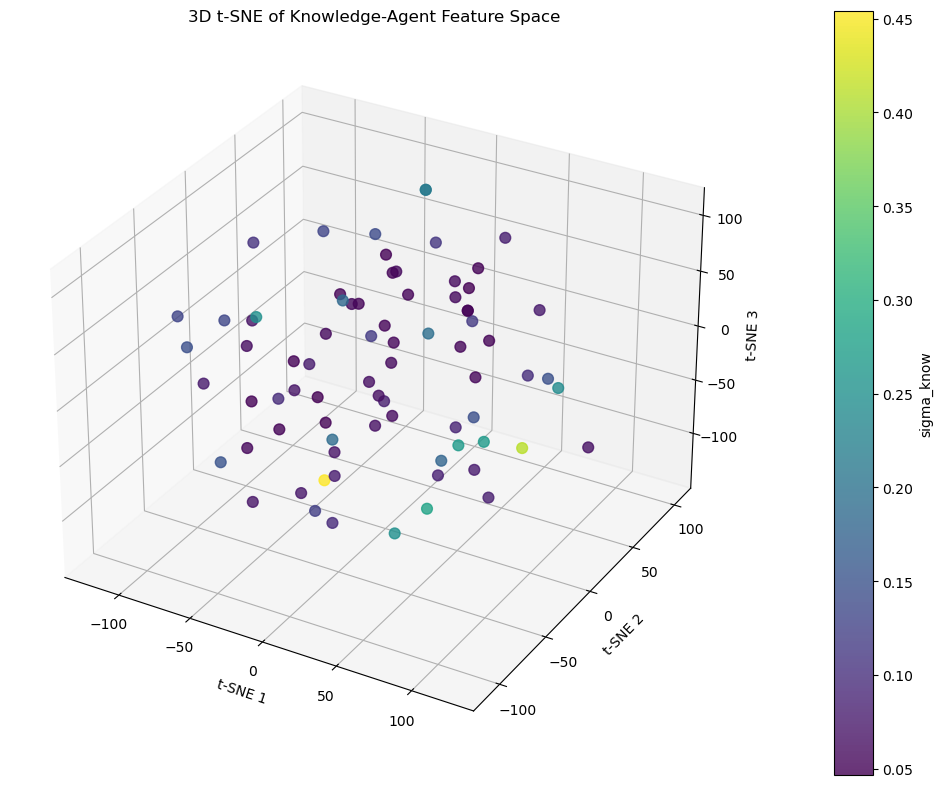

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Load original feature data
df_full = pd.read_csv("/home/henrykabuye/Ransap/Publications 2026/Proposal_2026/Knowledge_Agent/outputs/Knowledge_Agent_Features_307.csv")
df_out  = pd.read_csv("/home/henrykabuye/Ransap/Publications 2026/Proposal_2026/Knowledge_Agent/outputs/Knowledge_Agent_Output.csv")

# Merge outputs back to source data
df_plot = df_full.merge(df_out, on="Video_ID", how="inner")

drop_cols = [
    "Video_ID",
    "Channel_ID",
    "Channel_Name",
    "Video_Title",
    "YouTube_URL",
    "Transcript_Path",
    "Family_List",
    "Tool_List",
    "Dominant_Tactic",
    "Platform_Signal",
    "Family_Count"
]

X_plot = df_plot.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_plot)

# t-SNE to 3D
tsne = TSNE(
    n_components=3,
    perplexity=10,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

df_plot["TSNE1"] = X_tsne[:, 0]
df_plot["TSNE2"] = X_tsne[:, 1]
df_plot["TSNE3"] = X_tsne[:, 2]

# 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    df_plot["TSNE1"],
    df_plot["TSNE2"],
    df_plot["TSNE3"],
    c=df_plot["sigma_know"],
    s=60,
    alpha=0.8
)

ax.set_title("3D t-SNE of Knowledge-Agent Feature Space")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("sigma_know")

plt.tight_layout()
plt.show()

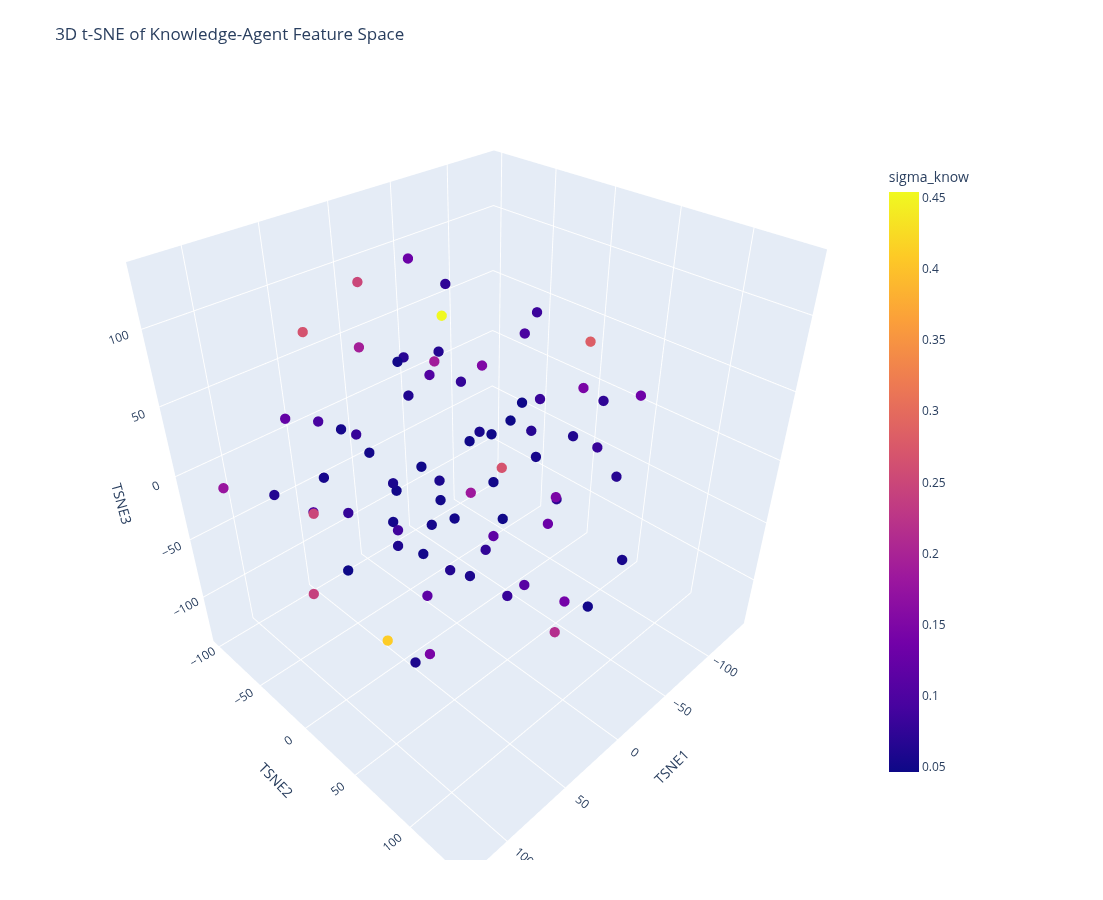

In [14]:
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

X_plot = df_plot.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_plot)

tsne = TSNE(
    n_components=3,
    perplexity=10,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

df_plot["TSNE1"] = X_tsne[:, 0]
df_plot["TSNE2"] = X_tsne[:, 1]
df_plot["TSNE3"] = X_tsne[:, 2]

fig = px.scatter_3d(
    df_plot,
    x="TSNE1",
    y="TSNE2",
    z="TSNE3",
    color="sigma_know",
    hover_data=["Video_ID", "s_know", "sigma_know", "Family_List"],
    title="3D t-SNE of Knowledge-Agent Feature Space"
)

fig.update_traces(marker=dict(size=6))
fig.update_layout(
    width=1400,
    height=900,
    margin=dict(l=40, r=180, b=40, t=80),
    coloraxis_colorbar=dict(
        title="sigma_know",
        x=0.95,
        len=0.8
    )
)

fig.show()